In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

2025-11-04 15:14:58.280761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762269298.564231      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762269298.636475      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


In [2]:
path = '/kaggle/input/pathogen-dataset/pathogen'

# Data Handling


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 30

In [4]:
#  a list of all image filepaths and their corresponding labels.
filepaths = []
labels = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        filepaths.append(os.path.join(dirname, filename))
        labels.append(os.path.basename(dirname))

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print("DataFrame created successfully. First 5 rows:")
print(df.head())

DataFrame created successfully. First 5 rows:
                                            filepath     label
0  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
1  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
2  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
3  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
4  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria


In [5]:
# Splitting the Data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

num_classes = len(df['label'].unique())
print(f"Number of classes found: {num_classes}")


Training samples: 31997
Validation samples: 4000
Test samples: 4000
Number of classes found: 5


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input 
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 31997 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.


# BUILD THE MODEL

In [7]:
# Load the base EfficientNetB0 model, pre-trained on ImageNet
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model to use it as a feature extractor
base_model.trainable = False

# Create our custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
num_classes = num_classes
outputs = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1762269395.232032      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762269395.232767      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# TRAINING MODEL

In [8]:
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max'
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.000001, 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [9]:
print("\nStarting Initial Training (Frozen Base Model)")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[model_checkpoint, early_stopping]
)


Starting Initial Training (Frozen Base Model)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1762269414.742851      60 service.cc:148] XLA service 0x7fc834113d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762269414.744066      60 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762269414.744087      60 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762269416.586612      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.2031 - loss: 1.7974   

I0000 00:00:1762269426.047312      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.5546 - loss: 1.1837
Epoch 1: val_accuracy improved from -inf to 0.87075, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 651s 625ms/step - accuracy: 0.5548 - loss: 1.1834 - val_accuracy: 0.8708 - val_loss: 0.5178
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8642 - loss: 0.4965
Epoch 2: val_accuracy improved from 0.87075 to 0.90500, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 420s 420ms/step - accuracy: 0.8642 - loss: 0.4965 - val_accuracy: 0.9050 - val_loss: 0.3632
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8976 - loss: 0.3588
Epoch 3: val_accuracy improved from 0.90500 to 0.91825, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 401s 401ms/step - accuracy: 0.8976 - loss: 0.3588 - val_accuracy: 0.9183 - val_loss: 0.2966
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9160 - loss: 0.2957
Epoch 4: val_accur

# FINE-TUNING

In [10]:
print("\n--- Starting Fine-Tuning Phase ---")

base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 100),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    initial_epoch=history.epoch[-1],
    callbacks=[model_checkpoint, early_stopping, lr_scheduler]
)


--- Starting Fine-Tuning Phase ---
Epoch 30/30


E0000 00:00:1762281798.406784      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281798.550638      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281799.004447      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281799.145741      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  75/1000 ━━━━━━━━━━━━━━━━━━━━ 6:14 405ms/step - accuracy: 0.7073 - loss: 0.8644

E0000 00:00:1762281849.585217      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281849.728704      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281850.188522      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762281850.329605      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7533 - loss: 0.7164
Epoch 30: val_accuracy did not improve from 0.96225
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 515s 457ms/step - accuracy: 0.7533 - loss: 0.7163 - val_accuracy: 0.8898 - val_loss: 0.3292 - learning_rate: 1.0000e-06
Restoring model weights from the end of the best epoch: 30.


# FINAL EVALUATION


--- Preparing Final Analysis ---

--- Plotting Combined Learning Curves ---


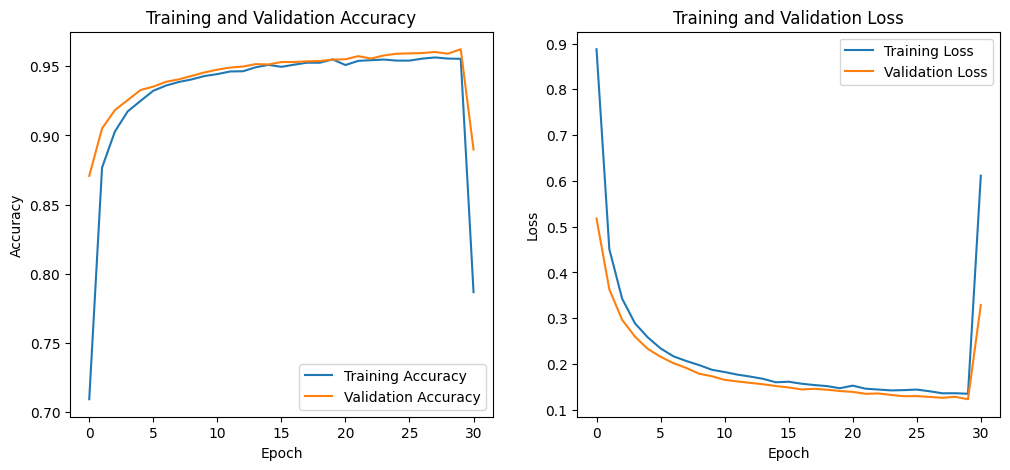


--- Loading the best performing model from 'best_model.keras' ---

--- Evaluating the BEST Performing Model on the Test Set ---
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 276ms/step - accuracy: 0.9667 - loss: 0.1171
Final Test Accuracy: 96.60%


In [11]:
print("\n--- Preparing Final Analysis ---")

if 'history' in locals() and 'history_fine' in locals():
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']
else:
    acc = history_fine.history['accuracy']
    val_acc = history_fine.history['val_accuracy']
    loss = history_fine.history['loss']
    val_loss = history_fine.history['val_loss']
    
if val_acc and val_loss:
    print("\n--- Plotting Combined Learning Curves ---")
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('/kaggle/working/Learning_Curve_plot.png')
    plt.show()                                                  

print("\n--- Loading the best performing model from 'best_model.keras' ---")
best_model = tf.keras.models.load_model('best_model.keras')

print("\n--- Evaluating the BEST Performing Model on the Test Set ---")
loss, accuracy = best_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

In [12]:
print("\nExporting the Best Model")

# 1. Export to Keras SavedModel Format
best_model.save('pathogen_model.keras')
print("Successfully exported to Keras SavedModel format: 'pathogen_model_keras'")

print("\nExporting to TFLite Format")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] 
tflite_model = converter.convert()

# Save the TFLite model file
with open('pathogen_model_final.tflite', 'wb') as f:
    f.write(tflite_model)
print("Successfully exported TFLite model: 'pathogen_model_final.tflite'")

# Export Class Names
class_names = list(train_generator.class_indices.keys())
with open('pathogen_labels_final.txt', 'w') as f:
    f.write('\n'.join(class_names))
print("Successfully exported labels: 'pathogen_labels_final.txt'")


Exporting the Best Model
Successfully exported to Keras SavedModel format: 'pathogen_model_keras'

Exporting to TFLite Format
Saved artifact at '/tmp/tmp7p8ok854'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140497157245840: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140497157248720: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140497256780176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140497256785552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140497256786512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140497256785744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140497256784400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140497256785360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1404972567

W0000 00:00:1762282359.867966      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762282359.868019      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1762282360.059945      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


Successfully exported TFLite model: 'pathogen_model_final.tflite'
Successfully exported labels: 'pathogen_labels_final.txt'


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


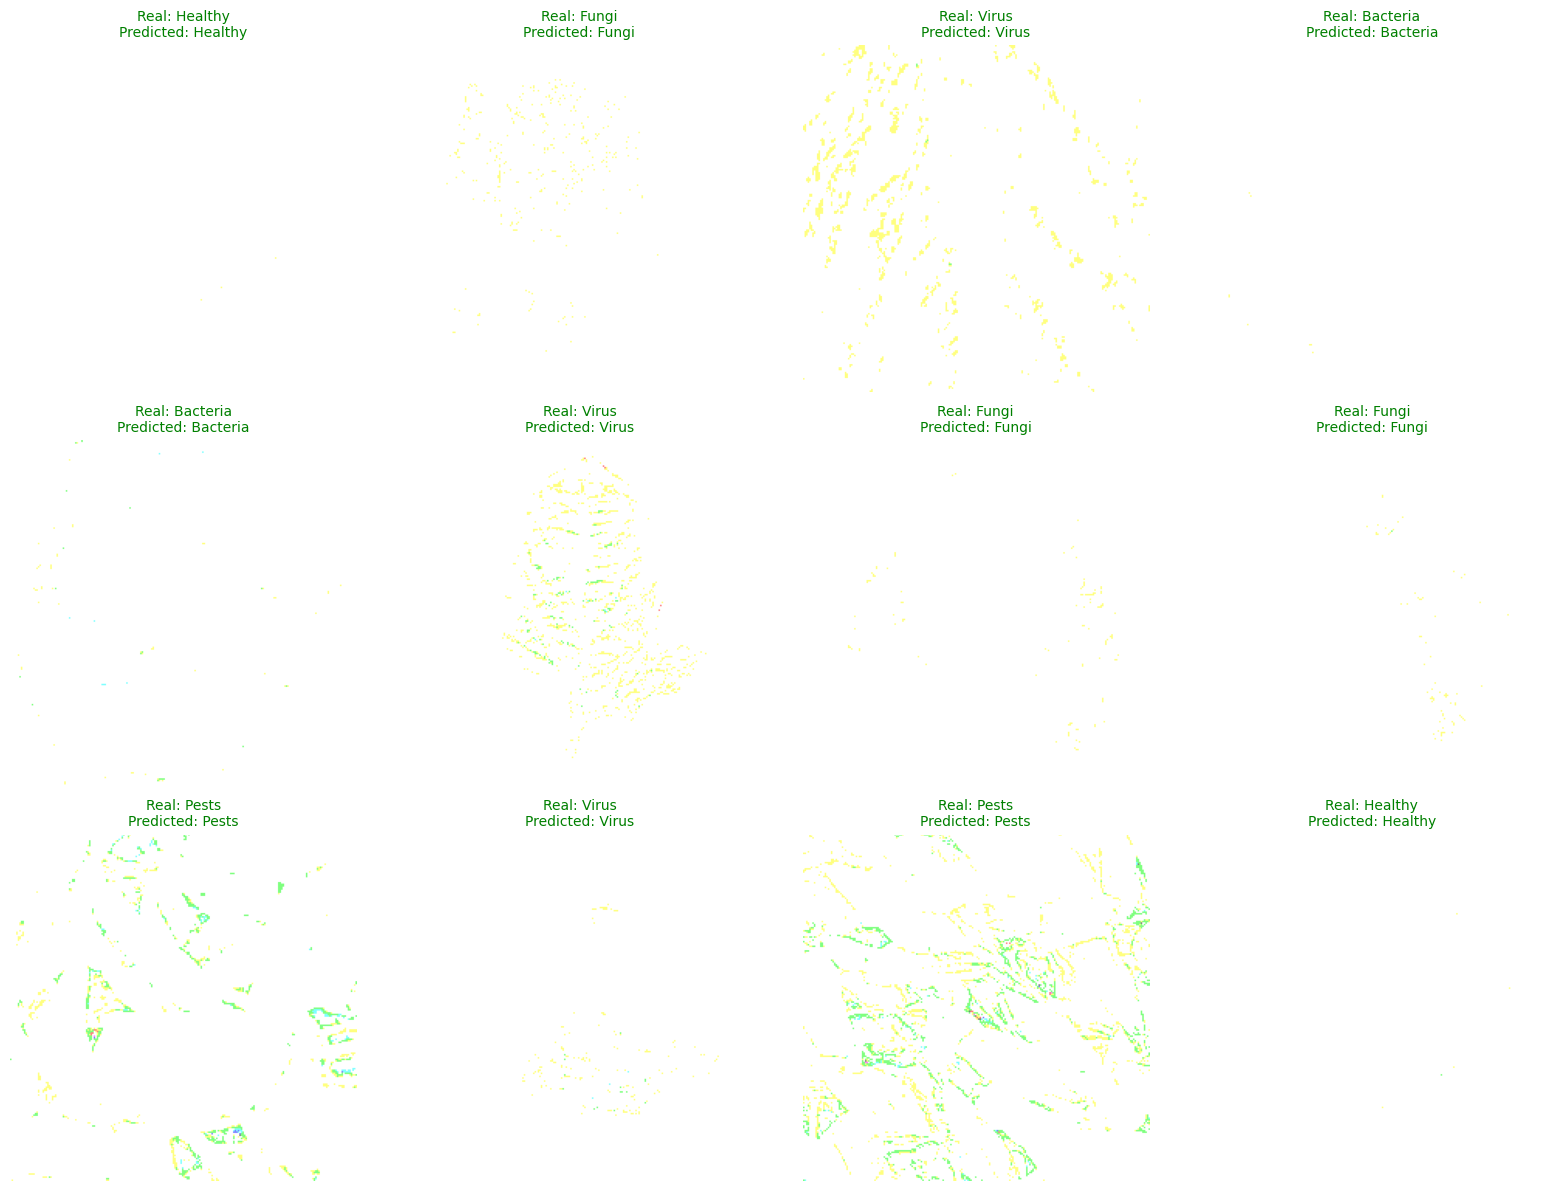

In [13]:
batch = next(test_generator)
images, labels = batch

predictions = best_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

class_names_list = list(class_names)

def deprocess_image(img):
    return (img + 1) / 2.0

plt.figure(figsize=(16, 12))
for i in range(12):
    if i >= len(images): 
        break
    plt.subplot(3, 4, i + 1)
    plt.imshow(deprocess_image(images[i]))
    
    real_label = class_names_list[np.argmax(labels[i])]
    predicted_label = class_names_list[predicted_labels[i]]
    
    title_color = 'green' if real_label == predicted_label else 'red'
    
    plt.title(f'Real: {real_label}\nPredicted: {predicted_label}', fontsize=10, color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/Batch_Predection_plot.png')
plt.show()

In [14]:
print("Preparing to test the model")

MODEL_PATH = '/kaggle/working/pathogen_model_final.tflite'
LABELS_PATH = '/kaggle/working/pathogen_labels_final.txt'
TEST_IMAGE_PATH = '/kaggle/input/pathogen123/fungi.jpeg'

# Load the Model and Labels
with open(LABELS_PATH, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
print(f"Loaded {len(class_names)} class labels.")

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
_, height, width, _ = input_details[0]['shape']

print(f"Model expects input shape: ({height}, {width})")

img = image.load_img(TEST_IMAGE_PATH, target_size=(height, width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preprocessed_img = preprocess_input(img_array)

# Make a Prediction
interpreter.set_tensor(input_details[0]['index'], preprocessed_img)
interpreter.invoke()
predictions = interpreter.get_tensor(output_details[0]['index'])

# Interpret and Display the Result
predicted_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_index]
confidence_score = np.max(predictions[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}\\nConfidence: {confidence_score*100:.2f}%")
plt.axis("off")
plt.savefig('/kaggle/working/Model_Test.png')
plt.show()

print("\nPrediction complete.")

Preparing to test the model
Loaded 5 class labels.
Model expects input shape: (224, 224)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


NameError: name 'image' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

MODEL_PATH = '/kaggle/working/pathogen_model_keras'
LABELS_PATH = '/kaggle/input/pathogen-identifier/tflite/default/1/pathogen_labels_final.txt'
TEST_IMAGE_PATH = '/kaggle/input/pathogen123/Bacteria leaf.jpg'
IMG_SIZE = 512

try:
    # 1. Load the Model and Labels
    print(f"Loading model from: {MODEL_PATH}...")
    model = tf.keras.models.load_model(MODEL_PATH)

    with open(LABELS_PATH, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(class_names)} class labels.")

    # 2. Load and Preprocess the Test Image
    print(f"\nProcessing image: {TEST_IMAGE_PATH}...")
    
    # Load and resize the image
    img = image.load_img(TEST_IMAGE_PATH, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    
    # Add a batch dimension: (512, 512, 3) -> (1, 512, 512, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Apply MobileNetV2 Preprocessing (scales to [-1, 1] range)
    preprocessed_img = preprocess_input(img_array)

    # 3. Make Prediction
    print("Making prediction...")
    predictions = model.predict(preprocessed_img)

    # 4. Interpret the Result
    predicted_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_index]
    confidence_score = np.max(predictions[0])

    print("\n--- Prediction Result ---")
    print(f"Predicted Disease/Pathogen: **{predicted_class_name}**")
    print(f"Confidence: **{confidence_score * 100:.2f}%**")
    
    # Optional: Display the image with the prediction
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name}\nConfidence: {confidence_score*100:.2f}%")
    plt.axis("off")
    plt.savefig('/kaggle/working/Model_Test2.png')    
    plt.show()
    
except FileNotFoundError:
    print(f"\nERROR: One or more required files (model, labels, or image) not found in the current directory.")
except Exception as e:
    print(f"\nAn error occurred during prediction: {e}")